# Visium H&E Model Comparison

This notebook:
1. Loads the Visium H&E dataset (unimodal spatial RNA).
2. Loads all trained topic models under `/data/omics_topic_models/sctm_comparison`.
3. Selects the best model by spatial autocorrelation (Moran's I).
4. Loads baseline models: scVI, STAMP, and AmortizedLDA.
5. Compares all models via UMAP and spatial plots colored by Leiden clustering.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

MODELS_DIR = Path("/data/omics_topic_models/sctm_comparison")
BASELINES_DIR = MODELS_DIR / "baselines"

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi

## 1. Load Visium H&E data

In [2]:
def load_data():
    """Load and preprocess Visium H&E data."""
    adata = sq.datasets.visium_hne_adata()

    # Use raw counts
    adata.X = adata.raw.X.copy()
    adata.layers["counts"] = adata.X.copy()

    # Build spatial neighbor graph if not present
    if "spatial_connectivities" not in adata.obsp:
        sq.gr.spatial_neighbors(adata, coord_type="generic")

    print(f"Spots: {adata.n_obs}")
    print(f"Genes: {adata.n_vars}")

    return adata


adata = load_data()
spatial_coords = adata.obsm["spatial"]

Spots: 2688
Genes: 18078


## 2. Helper functions for Moran's I and metrics

In [3]:
def parse_model_config(dirname):
    """Parse hyperparameter configuration from directory name."""
    config = {}
    if "horseshoe" in dirname:
        config["feature_prior_type"] = "horseshoe"
    else:
        config["feature_prior_type"] = "logistic_normal"

    if "learnable_disp_global" in dirname:
        config["dispersion"] = "learnable_global"
    elif "learnable_disp_pergene" in dirname:
        config["dispersion"] = "learnable_pergene"
    else:
        config["dispersion"] = "fixed"
    
    # Parse GCN layers
    if "gcn" in dirname:
        import re
        match = re.search(r'gcn(\d+)', dirname)
        config["gcn_layers"] = int(match.group(1)) if match else 1
    else:
        config["gcn_layers"] = 1

    return config


def compute_moran_i(values, spatial_weights):
    """Compute Moran's I statistic for a 1D array of values."""
    n = len(values)
    z = values - values.mean()
    
    W = spatial_weights.tocsr()
    numerator = z @ W @ z
    denominator = z @ z
    
    if denominator == 0:
        return 0.0
    
    S0 = W.sum()
    if S0 == 0:
        return 0.0
    
    return (n / S0) * (numerator / denominator)


def compute_spatial_metrics(latent, spatial_coords, adata_ref, n_neighbors=6):
    """
    Compute spatial autocorrelation (Moran's I) and Leiden clustering.
    Uses the spatial graph from the reference adata.
    """
    adata_temp = ad.AnnData(np.asarray(latent))
    adata_temp.obsm["spatial"] = np.asarray(spatial_coords)

    # Leiden clustering on latent space
    sc.pp.neighbors(adata_temp, use_rep="X", n_neighbors=15, metric="cosine")
    sc.tl.leiden(adata_temp, key_added="leiden", resolution=0.5)

    # Use spatial weights from reference adata
    spatial_weights = adata_ref.obsp["spatial_connectivities"]
    
    # Compute Moran's I for each latent dimension
    morans_values = [compute_moran_i(latent[:, i], spatial_weights) for i in range(latent.shape[1])]

    return {
        "morans_i": np.mean(morans_values),
        "n_clusters": len(adata_temp.obs["leiden"].unique()),
        "leiden": adata_temp.obs["leiden"].values
    }

## 3. Load topic models

In [4]:
# Find all model directories
if not MODELS_DIR.exists():
    print(f"Warning: Models directory does not exist: {MODELS_DIR}")
    model_dirs = []
else:
    model_dirs = sorted(
        [d for d in MODELS_DIR.iterdir() if d.is_dir() and d.name.startswith("prior_")]
    )
print(f"Found {len(model_dirs)} candidate model dirs")

Found 7 candidate model dirs


In [5]:
results = []

for model_dir in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        continue

    print(f"Loading {model_dir.name}...")
    
    # Try to load pre-saved latent representation first
    latent_path = model_dir / "latent_representation.npy"
    theta_path = model_dir / "theta.npy"
    
    theta_array = None
    
    if latent_path.exists():
        theta_array = np.load(latent_path)
        print(f"  Loaded pre-saved latent from {latent_path}")
    elif theta_path.exists():
        theta_array = np.load(theta_path)
        print(f"  Loaded pre-saved theta from {theta_path}")
    else:
        # Try loading model directly (works for non-GCN or simple GCN models)
        try:
            from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA
            
            # Load a fresh copy of adata for setup
            adata_temp = sq.datasets.visium_hne_adata()
            adata_temp.X = adata_temp.raw.X.copy()
            if "spatial_connectivities" not in adata_temp.obsp:
                sq.gr.spatial_neighbors(adata_temp, coord_type="generic")
            
            model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_temp)
            theta_df = model.get_latent_representation(adata_temp, batch_size=adata_temp.n_obs)
            theta_array = theta_df.values
            print(f"  Loaded model directly and computed latents")
        except Exception as e:
            print(f"  Could not load model directly: {e}")
            continue
    
    if theta_array is None:
        print(f"  No latent found, skipping")
        continue
    
    config = parse_model_config(model_dir.name)

    try:
        metrics = compute_spatial_metrics(theta_array, spatial_coords, adata)
        
        result = {
            "model_name": model_dir.name,
            **config,
            "morans_i": metrics["morans_i"],
            "n_clusters": metrics["n_clusters"],
            "theta": theta_array,
            "leiden": metrics["leiden"],
        }
        results.append(result)
        print(f"  Moran's I: {metrics['morans_i']:.4f}")
    except Exception as e:
        print(f"  Error computing metrics: {e}")

print(f"\nSuccessfully loaded {len(results)} models")

Loading prior_horseshoe...
INFO     File /data/omics_topic_models/sctm_comparison/prior_horseshoe/model/model.pt already downloaded           


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<03:52,  4.29it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<04:02,  4.12it/s, v_num=1]
  Loaded model directly and computed latents
  Moran's I: 0.3659
Loading prior_horseshoe_learnable_disp_global...
INFO     File /data/omics_topic_models/sctm_comparison/prior_horseshoe_learnable_disp_global/model/model.pt already
         downloaded                                                                                                


...

Epoch 1/1000:   0%|          | 1/1000 [00:00<00:46, 21.71it/s, v_num=1]
  Loaded model directly and computed latents
  Moran's I: 0.4763
Loading prior_logistic_normal_learnable_disp_pergene...
INFO     File /data/omics_topic_models/sctm_comparison/prior_logistic_normal_learnable_disp_pergene/model/model.pt 
         already downloaded                                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<00:49, 20.02it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<00:55, 18.16it/s, v_num=1]
  Loaded model directly and computed latents
  Moran's I: 0.6058

Successfully loaded 7 models


## 4. Select best topic model

In [6]:
if results:
    results_display = [{k: v for k, v in r.items() if k not in ["theta", "leiden"]} for r in results]
    df_results = pd.DataFrame(results_display)

    # Sort by Moran's I - higher is better
    df_sorted = df_results.sort_values("morans_i", ascending=False)
    print("Model Comparison (sorted by Moran's I):")
    print(df_sorted.to_string(index=False))

    best_idx = df_sorted["morans_i"].idxmax()
    best_model_name = df_sorted.loc[best_idx, "model_name"]
    best_result = next(r for r in results if r["model_name"] == best_model_name)

    print(f"\nBest model: {best_model_name}")
    print(f"  Feature prior: {best_result['feature_prior_type']}")
    print(f"  Dispersion: {best_result['dispersion']}")
    print(f"  Moran's I: {best_result['morans_i']:.4f}")

    theta_best = best_result["theta"]
else:
    print("No topic models loaded.")
    theta_best = None
    df_sorted = None

Model Comparison (sorted by Moran's I):
                                  model_name feature_prior_type        dispersion  gcn_layers  morans_i  n_clusters
prior_logistic_normal_learnable_disp_pergene    logistic_normal learnable_pergene           1  0.605827          10
                  prior_logistic_normal_gcn2    logistic_normal             fixed           2  0.590912          13
                       prior_logistic_normal    logistic_normal             fixed           1  0.579521          13
 prior_logistic_normal_learnable_disp_global    logistic_normal  learnable_global           1  0.476317          12
                             prior_horseshoe          horseshoe             fixed           1  0.365938           7
      prior_horseshoe_learnable_disp_pergene          horseshoe learnable_pergene           1  0.338141           7
       prior_horseshoe_learnable_disp_global          horseshoe  learnable_global           1  0.293870           7

Best model: prior_logistic_norm

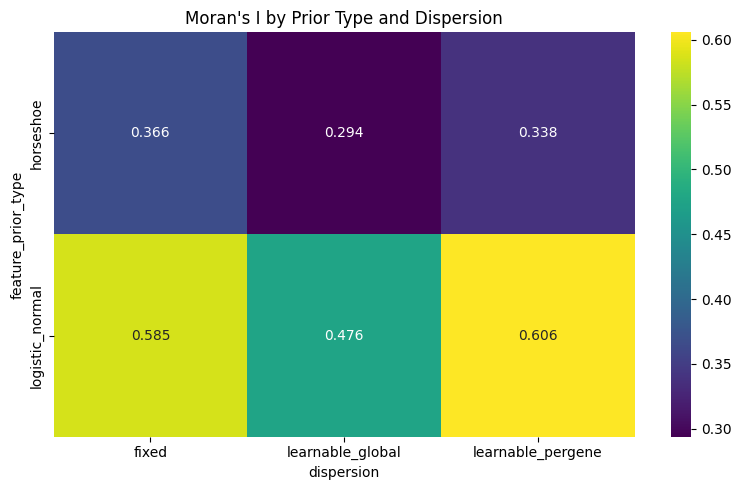

In [7]:
# Visualize topic model results
if results and len(results) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))

    df_pivot = df_sorted.pivot_table(
        values="morans_i", index="feature_prior_type", columns="dispersion", aggfunc="mean"
    )
    sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title("Moran's I by Prior Type and Dispersion")

    plt.tight_layout()
    plt.show()

## 5. Load baseline models

In [8]:
# Load scVI latent
latent_scvi = None
scvi_path = BASELINES_DIR / "latent_scvi.npy"
if scvi_path.exists():
    latent_scvi = np.load(scvi_path)
    print(f"Loaded scVI latent: {latent_scvi.shape}")
else:
    print(f"scVI latent not found: {scvi_path}")

# Load STAMP latent
latent_stamp = None
stamp_path = BASELINES_DIR / "latent_stamp.npy"
if stamp_path.exists():
    latent_stamp = np.load(stamp_path)
    print(f"Loaded STAMP latent: {latent_stamp.shape}")
else:
    print(f"STAMP latent not found: {stamp_path}")

# Load AmortizedLDA latent
latent_lda = None
lda_path = BASELINES_DIR / "latent_amortized_lda.npy"
if lda_path.exists():
    latent_lda = np.load(lda_path)
    print(f"Loaded AmortizedLDA latent: {latent_lda.shape}")
else:
    print(f"AmortizedLDA latent not found: {lda_path}")

Loaded scVI latent: (2688, 10)
Loaded STAMP latent: (2688, 10)
Loaded AmortizedLDA latent: (2688, 10)


## 6. Compute metrics for all models

In [9]:
def compute_metrics_for_latent(latent, name, spatial_coords, adata_ref):
    """Compute spatial metrics for a latent representation."""
    if latent is None:
        return None

    print(f"Computing metrics for {name}...")
    try:
        metrics = compute_spatial_metrics(latent, spatial_coords, adata_ref)
        return {
            "model": name,
            "morans_i": metrics["morans_i"],
            "n_clusters": metrics["n_clusters"],
            "latent": latent,
            "leiden": metrics["leiden"],
        }
    except Exception as e:
        print(f"  Error: {e}")
        return None


all_results = {}

if latent_scvi is not None:
    all_results["scVI"] = compute_metrics_for_latent(latent_scvi, "scVI", spatial_coords, adata)

if latent_stamp is not None:
    all_results["STAMP"] = compute_metrics_for_latent(latent_stamp, "STAMP", spatial_coords, adata)

if latent_lda is not None:
    all_results["AmortizedLDA"] = compute_metrics_for_latent(latent_lda, "AmortizedLDA", spatial_coords, adata)

# Add best topic model
if theta_best is not None:
    all_results["Omics-Topic (Best)"] = {
        "model": "Omics-Topic (Best)",
        "morans_i": best_result["morans_i"],
        "n_clusters": best_result["n_clusters"],
        "latent": theta_best,
        "leiden": best_result["leiden"],
    }

Computing metrics for scVI...
Computing metrics for STAMP...
Computing metrics for AmortizedLDA...


In [10]:
# Summary comparison table
if all_results:
    summary_data = []
    for name, res in all_results.items():
        if res is not None:
            summary_data.append({
                "Model": res["model"],
                "Moran's I": res["morans_i"],
                "N Clusters": res["n_clusters"],
            })

    summary_df = pd.DataFrame(summary_data).sort_values("Moran's I", ascending=False)
    print("\nSpatial Autocorrelation Comparison:")
    print(summary_df.to_string(index=False))
else:
    print("No models loaded for comparison.")
    summary_df = None


Spatial Autocorrelation Comparison:
             Model  Moran's I  N Clusters
             STAMP   0.762360          14
              scVI   0.727210          13
Omics-Topic (Best)   0.605827          10
      AmortizedLDA   0.451841          11


## 7. Performance comparison plot

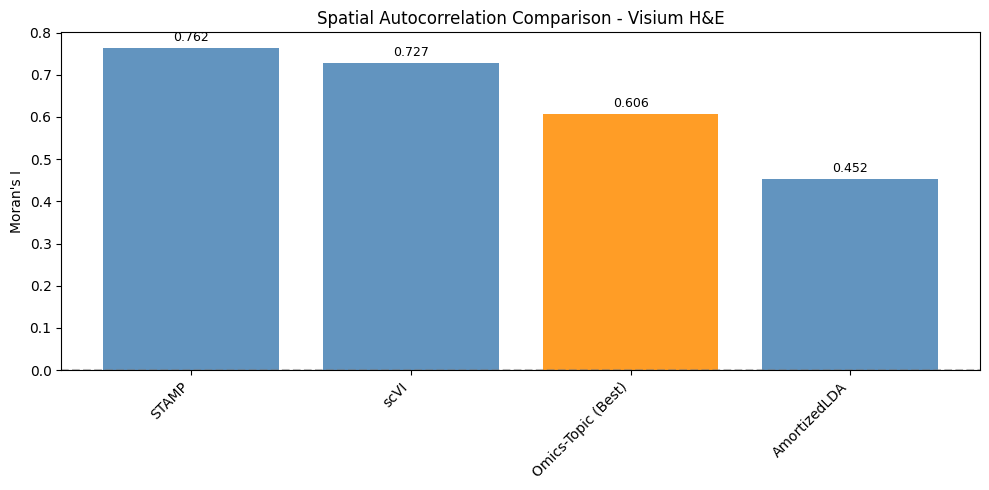


Saved comparison plot to: /data/omics_topic_models/sctm_comparison/baselines/spatial_comparison.png


In [11]:
if summary_df is not None and len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    colors = ["darkorange" if "Omics" in m else "steelblue" for m in summary_df["Model"]]
    bars = ax.bar(summary_df["Model"], summary_df["Moran's I"], color=colors, alpha=0.85)
    ax.set_ylabel("Moran's I")
    ax.set_title("Spatial Autocorrelation Comparison - Visium H&E")
    ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    
    for bar, val in zip(bars, summary_df["Moran's I"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()

    BASELINES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(BASELINES_DIR / "spatial_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"\nSaved comparison plot to: {BASELINES_DIR / 'spatial_comparison.png'}")

## 8. UMAP and Spatial plots

In [12]:
def plot_umap_and_spatial(latent, leiden, spatial_coords, title, figsize=(14, 5)):
    """
    Plot UMAP and spatial coordinates colored by Leiden clustering.
    """
    adata_temp = ad.AnnData(np.asarray(latent))
    adata_temp.obsm["spatial"] = np.asarray(spatial_coords)
    adata_temp.obs["leiden"] = pd.Categorical(leiden)

    # Compute UMAP
    sc.pp.neighbors(adata_temp, use_rep="X", n_neighbors=15, metric="cosine")
    sc.tl.umap(adata_temp, min_dist=0.3)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # UMAP
    sc.pl.umap(adata_temp, color="leiden", ax=axes[0], show=False, title=f"{title}: UMAP")

    # Spatial plot
    leiden_encoded = LabelEncoder().fit_transform(leiden)
    scatter = axes[1].scatter(
        spatial_coords[:, 0],
        spatial_coords[:, 1],
        c=leiden_encoded,
        cmap="tab20",
        s=15,
        alpha=0.8,
    )
    axes[1].set_title(f"{title}: Spatial")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].set_aspect("equal")
    axes[1].invert_yaxis()

    plt.tight_layout()
    return fig


Plotting scVI...


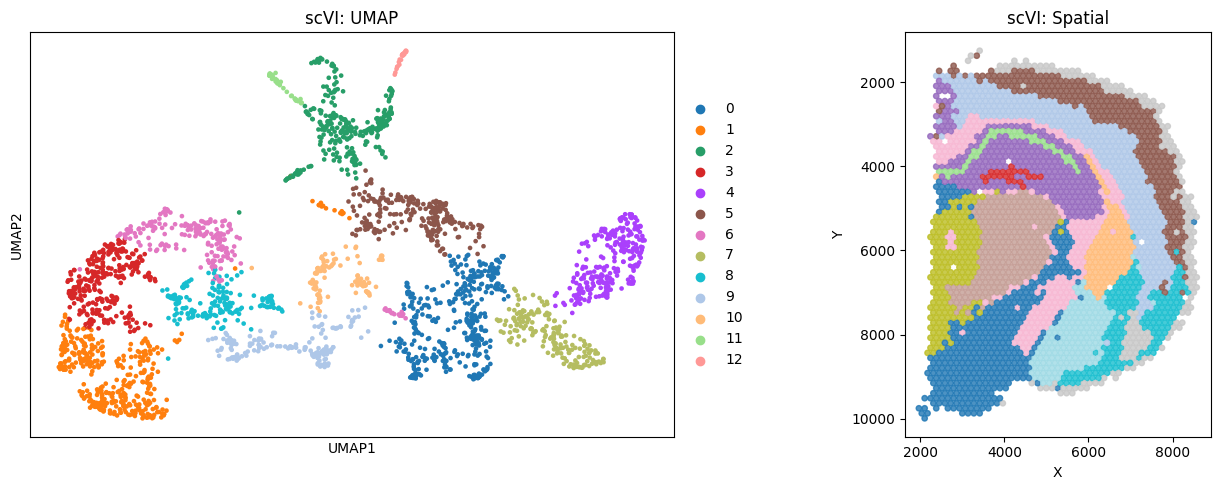

  Saved to: /data/omics_topic_models/sctm_comparison/baselines/umap_spatial_scvi.png

Plotting STAMP...


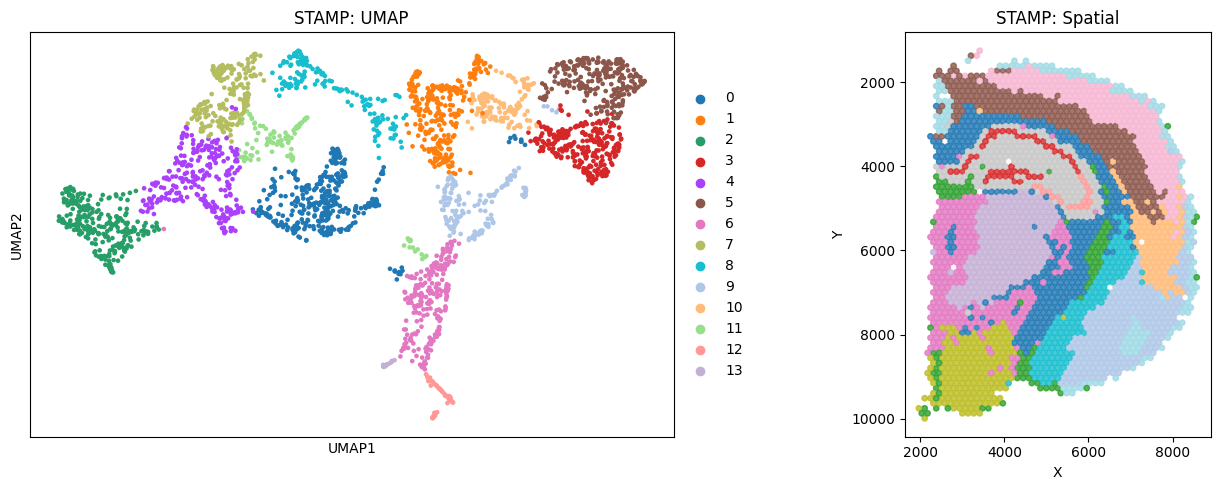

  Saved to: /data/omics_topic_models/sctm_comparison/baselines/umap_spatial_stamp.png

Plotting AmortizedLDA...


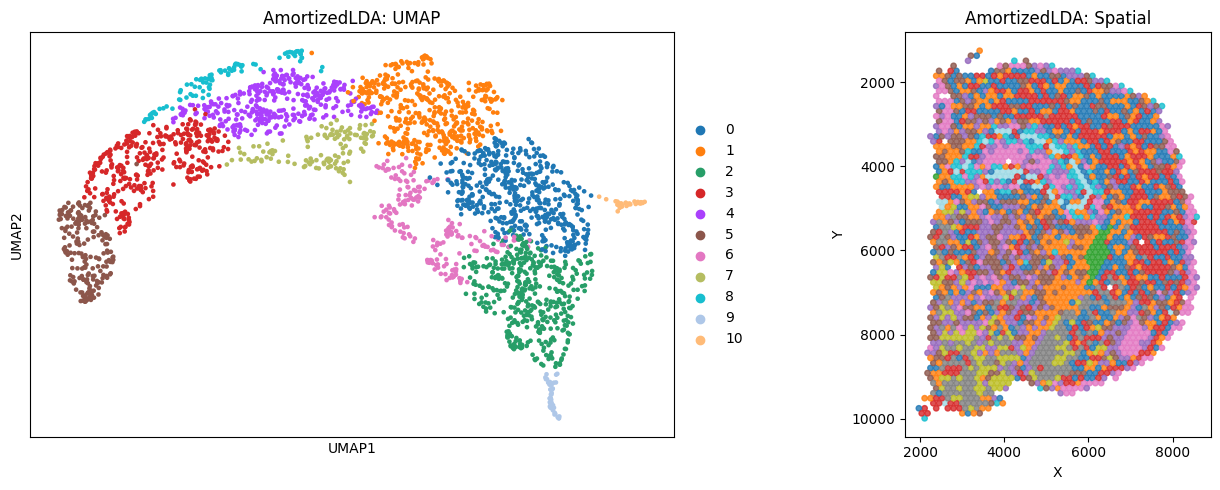

  Saved to: /data/omics_topic_models/sctm_comparison/baselines/umap_spatial_amortizedlda.png

Plotting Omics-Topic (Best)...


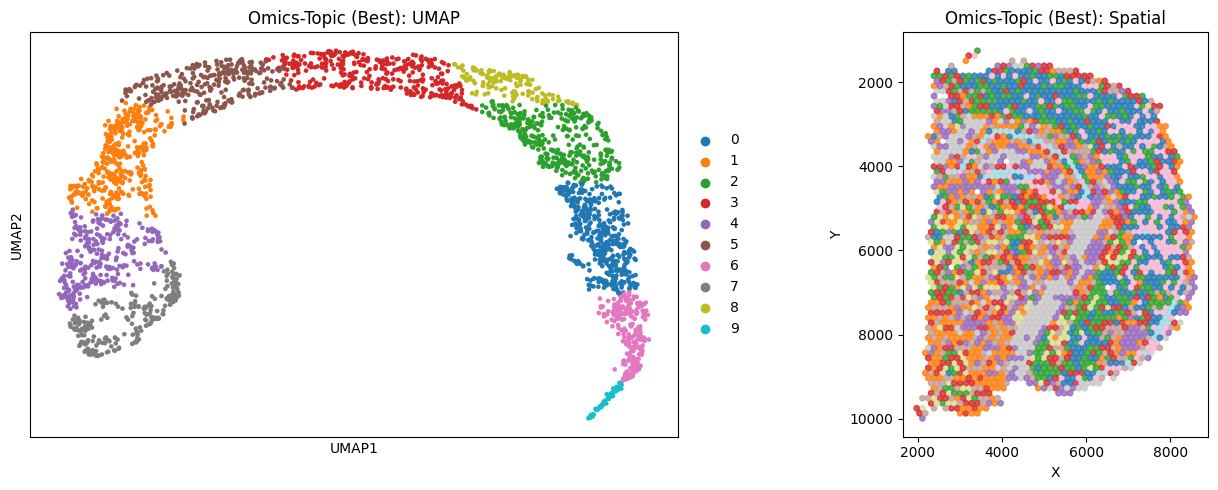

  Saved to: /data/omics_topic_models/sctm_comparison/baselines/umap_spatial_omics_topic_best.png


In [13]:
# Plot for all models
for name, res in all_results.items():
    if res is not None:
        print(f"\nPlotting {name}...")
        fig = plot_umap_and_spatial(
            res["latent"],
            res["leiden"],
            spatial_coords,
            name,
        )
        plt.show()

        # Save individual figures
        safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
        fig.savefig(BASELINES_DIR / f"umap_spatial_{safe_name}.png", dpi=200, bbox_inches="tight")
        print(f"  Saved to: {BASELINES_DIR / f'umap_spatial_{safe_name}.png'}")

## 9. Combined comparison figure

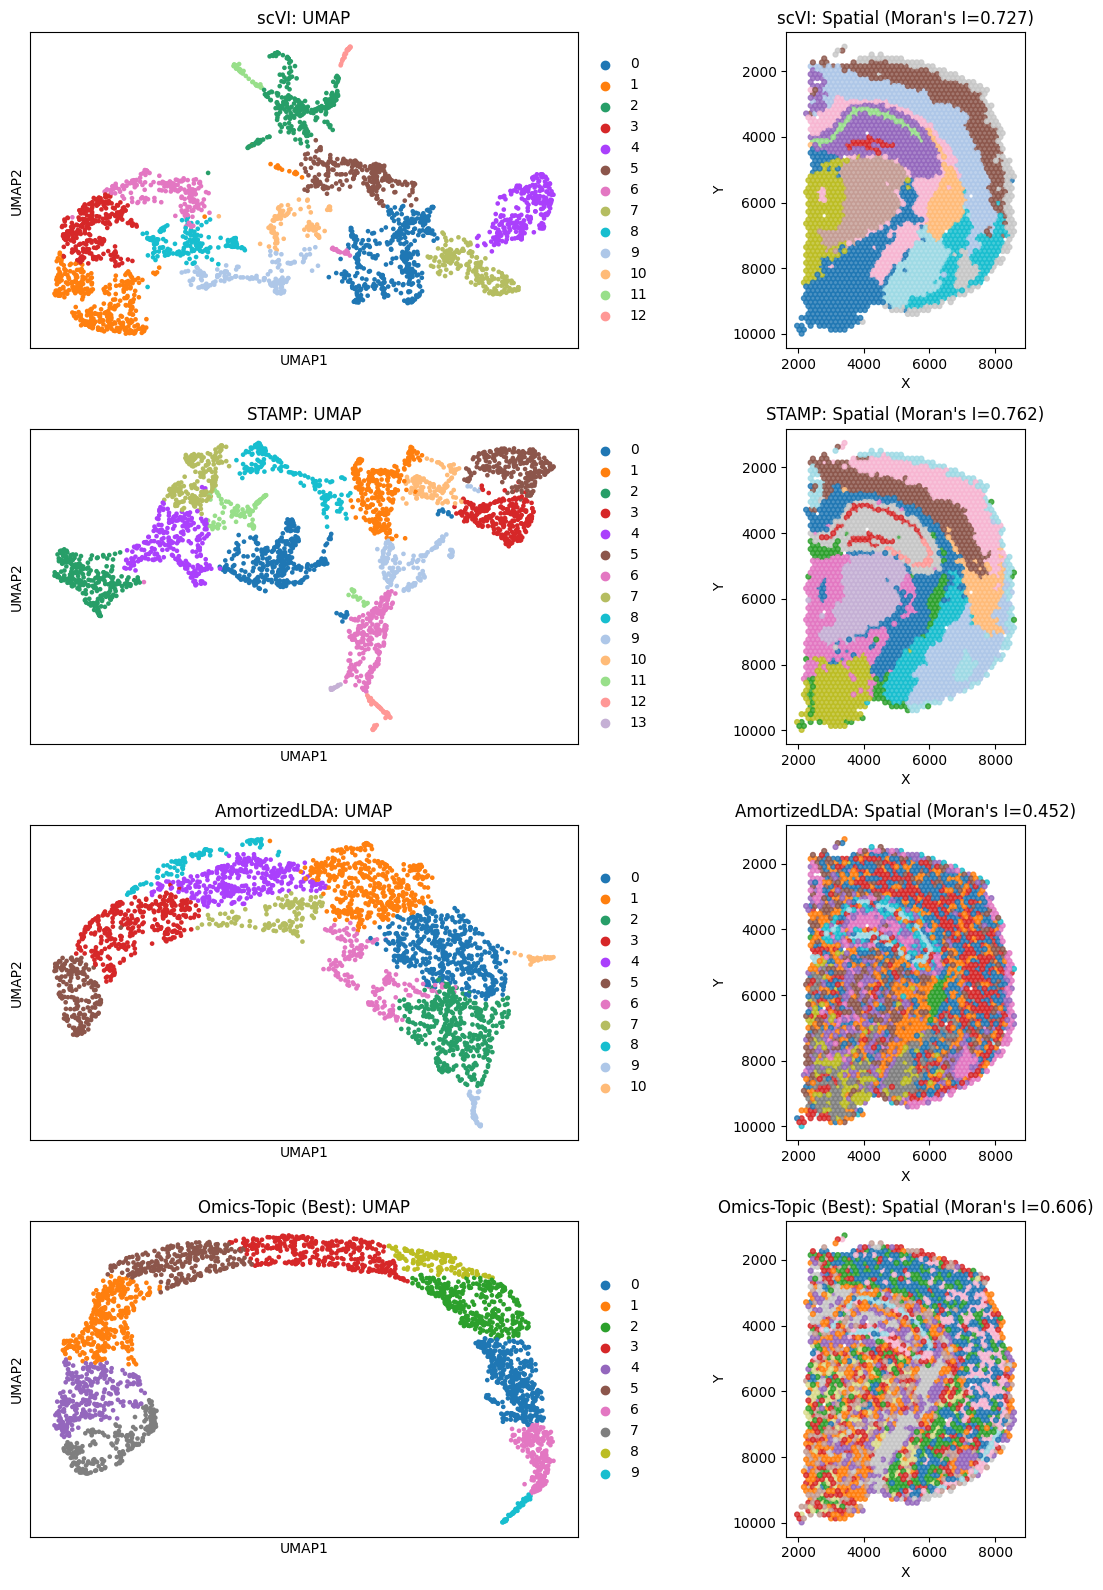


Saved combined comparison to: /data/omics_topic_models/sctm_comparison/baselines/combined_comparison.png


In [14]:
# Create a combined figure with all models
n_models = len([r for r in all_results.values() if r is not None])

if n_models > 0:
    fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)

    for idx, (name, res) in enumerate([(k, v) for k, v in all_results.items() if v is not None]):
        latent = res["latent"]
        leiden = res["leiden"]

        # Create temporary AnnData for UMAP
        adata_temp = ad.AnnData(np.asarray(latent))
        adata_temp.obsm["spatial"] = np.asarray(spatial_coords)
        adata_temp.obs["leiden"] = pd.Categorical(leiden)

        sc.pp.neighbors(adata_temp, use_rep="X", n_neighbors=15, metric="cosine")
        sc.tl.umap(adata_temp, min_dist=0.3)

        # UMAP
        sc.pl.umap(adata_temp, color="leiden", ax=axes[idx, 0], show=False, title=f"{name}: UMAP")

        # Spatial
        leiden_encoded = LabelEncoder().fit_transform(leiden)
        axes[idx, 1].scatter(
            spatial_coords[:, 0],
            spatial_coords[:, 1],
            c=leiden_encoded,
            cmap="tab20",
            s=12,
            alpha=0.8,
        )
        axes[idx, 1].set_title(f"{name}: Spatial (Moran's I={res['morans_i']:.3f})")
        axes[idx, 1].set_aspect("equal")
        axes[idx, 1].invert_yaxis()
        axes[idx, 1].set_xlabel("X")
        axes[idx, 1].set_ylabel("Y")

    plt.tight_layout()
    fig.savefig(BASELINES_DIR / "combined_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"\nSaved combined comparison to: {BASELINES_DIR / 'combined_comparison.png'}")

## 10. Save results

In [ ]:
# Save summary tables
BASELINES_DIR.mkdir(parents=True, exist_ok=True)

if summary_df is not None:
    summary_df.to_csv(BASELINES_DIR / "spatial_metrics_comparison.csv", index=False)
    print(f"Saved comparison metrics to: {BASELINES_DIR / 'spatial_metrics_comparison.csv'}")

if results:
    df_sorted.to_csv(BASELINES_DIR / "topic_model_metrics.csv", index=False)
    print(f"Saved topic model metrics to: {BASELINES_DIR / 'topic_model_metrics.csv'}")

Saved comparison metrics to: /data/omics_topic_models/sctm_comparison/baselines/spatial_metrics_comparison.csv
Saved topic model metrics to: /data/omics_topic_models/sctm_comparison/baselines/topic_model_metrics.csv


: 

## Notes

- This notebook expects trained topic models under `/data/omics_topic_models/sctm_comparison` with `prior_*` directories.
- Baseline outputs are expected under `/data/omics_topic_models/sctm_comparison/baselines`.
- The best model is selected by **Moran's I**, which measures spatial autocorrelation.
- Higher Moran's I indicates the latent representation captures spatial structure better.
- scVI is a deep generative model (not topic-based), STAMP is a spatial topic model, and AmortizedLDA is a non-spatial topic model.